<a href="https://colab.research.google.com/github/soonhyeong/NVIDIA_AI_Edu/blob/main/015_project10ipynb.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install -q koreanize-matplotlib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import koreanize_matplotlib
plt.rcParams['axes.unicode_minus'] = False
print("준비 완료")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.9/7.9 MB 41.5 MB/s eta 0:00:00
준비 완료


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
call_df = pd.read_csv("/content/drive/MyDrive/DATA/Calldata_2008.csv", encoding = "utf-8", parse_dates = ["일자(YYYYMMDD)"])
call_df.columns = ["일자", "연령","성별","발신지1","발신지2","대분류","중분류","통화비율"]
call_df

,일자,연령,성별,발신지1,발신지2,대분류,중분류,통화비율
0,2020-08-18,40,여성,강원,강릉시,서비스산업,수리/AS,0.0002
1,2020-08-24,40,남성,강원,강릉시,여행,숙박,0.0001
2,2020-08-31,60,여성,강원,강릉시,음식점,한식,0.0001
3,2020-08-01,40,여성,강원,강릉시,생활편의,생활서비스,0.0001
4,2020-08-11,60,남성,강원,강릉시,생활편의,생활편의,0.0003
...,...,...,...,...,...,...,...,...
556411,2020-08-31,60,여성,충북,청주시,생활편의,생활편의,0.0003
556412,2020-08-31,50,남성,충북,청주시,생활편의,생활서비스,0.0001
556413,2020-08-24,40,여성,충북,청주시,음식점,치킨,0.0002
556414,2020-08-24,20,여성,충북,청주시,금융편의,제2금융,0.0002


In [ ]:
rain_df = pd.read_csv("/content/drive/MyDrive/DATA/Raindata_2008.csv", encoding = "cp949", parse_dates = ["일시"])
rain_df.columns = ["지점번호", "지점명", "일자", "강수량", "1시간최대강수량", "1시간최대강수량시각"]
rain_df

,지점번호,지점명,일자,강수량,1시간최대강수량,1시간최대강수량시각
0,\t108,서울,2020-08-01,39.1,23.6,12:22
1,\t108,서울,2020-08-02,31.4,13.8,15:33
2,\t108,서울,2020-08-03,102.6,28.5,8:36
3,\t108,서울,2020-08-04,3.9,1.8,6:36
4,\t108,서울,2020-08-05,18.5,14.4,23:25
5,\t108,서울,2020-08-06,75.7,19.9,4:15
6,\t108,서울,2020-08-07,0.0,0.0,NaN
7,\t108,서울,2020-08-08,19.1,5.9,20:26
8,\t108,서울,2020-08-09,50.3,13.9,13:37
9,\t108,서울,2020-08-10,44.6,28.6,15:56


In [ ]:
call_df["대분류"].unique()

array(['서비스산업', '여행', '음식점', '생활편의', '스포츠/레저', '금융편의', '쇼핑', '의료편의',
       '교통편의', '공공편의', '교육/학문', '기업/단체', '건물/시설', '이벤트'], dtype=object)

In [ ]:
is_true = (call_df["발신지1"] == "서울") & (call_df["대분류"] == "음식점")
call_df = call_df[is_true]
call_df

KeyError: '발신지1'

In [ ]:
call_df = call_df.drop(columns = ["성별", "발신지1", "발신지2", "통화비율", "대분류"])
call_df

,일자,중분류
161040,2020-08-23,중식
161050,2020-08-30,양식
161053,2020-08-25,치킨
161059,2020-08-09,치킨
161065,2020-08-09,중식
...,...,...
461626,2020-08-19,한식
461636,2020-08-21,한식
461648,2020-08-04,한식
461650,2020-08-15,치킨


In [ ]:
rain_df = rain_df.drop(columns = ["지점번호", "지점명", "1시간최대강수량","1시간최대강수량시각"])
rain_df

,일자,강수량
0,2020-08-01,39.1
1,2020-08-02,31.4
2,2020-08-03,102.6
3,2020-08-04,3.9
4,2020-08-05,18.5
5,2020-08-06,75.7
6,2020-08-07,0.0
7,2020-08-08,19.1
8,2020-08-09,50.3
9,2020-08-10,44.6


In [ ]:
rain_df["강수량"] = rain_df["강수량"].fillna(0)
rain_df

,일자,강수량
0,2020-08-01,39.1
1,2020-08-02,31.4
2,2020-08-03,102.6
3,2020-08-04,3.9
4,2020-08-05,18.5
5,2020-08-06,75.7
6,2020-08-07,0.0
7,2020-08-08,19.1
8,2020-08-09,50.3
9,2020-08-10,44.6


In [ ]:
tot_df = pd.merge(call_df, rain_df, on = '일자')
tot_df

,일자,중분류,강수량
0,2020-08-23,중식,0.0
1,2020-08-30,양식,42.5
2,2020-08-25,치킨,0.0
3,2020-08-09,치킨,50.3
4,2020-08-09,중식,50.3
...,...,...,...
7716,2020-08-19,한식,0.0
7717,2020-08-21,한식,2.5
7718,2020-08-04,한식,3.9
7719,2020-08-15,치킨,69.0


In [ ]:
no_rain = tot_df[tot_df["강수량"]==0] # tot_df 에서 강수량이 0, 즉 비가 안오는날의 음식 주문 데이터

no_rain = pd.DataFrame(no_rain["중분류"].value_counts()) # 비가 안오는 날 음식 종류별 주문 수

no_rain

,count
중분류,
한식,1857
중식,330
치킨,326
양식,61
카페,22
분식,14


In [ ]:
yes_rain = tot_df[tot_df["강수량"] >= 50]

yes_rain = pd.DataFrame(yes_rain["중분류"].value_counts())

yes_rain

,count
중분류,
한식,798
치킨,252
중식,164
양식,24
카페,6
분식,2


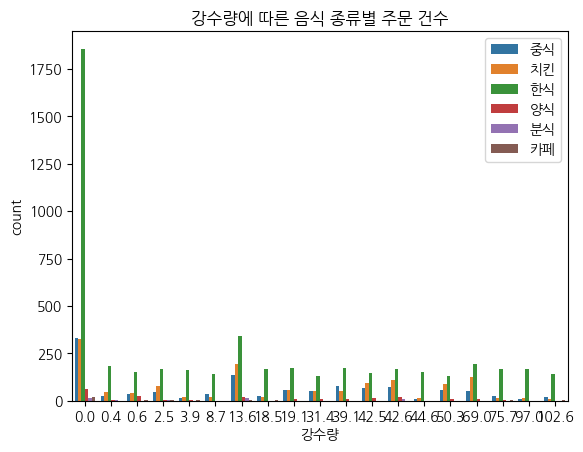

In [ ]:
plt.title("강수량에 따른 음식 종류별 주문 건수")

sns.countplot(data = tot_df, x = "강수량", hue = "중분류")
plt.legend()
plt.show()

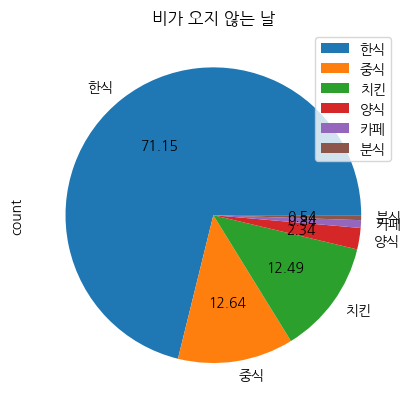

In [ ]:

no_rain.plot.pie(y = "count", autopct= "%.2f")
plt.title("비가 오지 않는 날")
plt.show()

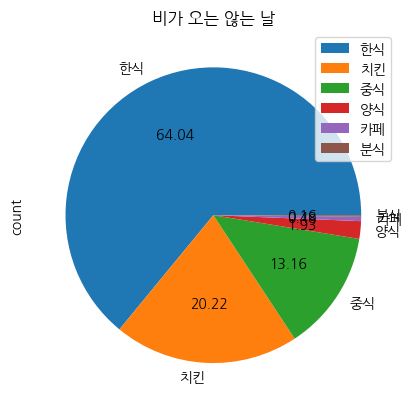

In [ ]:
yes_rain.plot.pie(y = "count", autopct= "%.2f")
plt.title("비가 오는 않는 날")
plt.show()

[Text(0.5, 1.0, '비가 오는 날')]

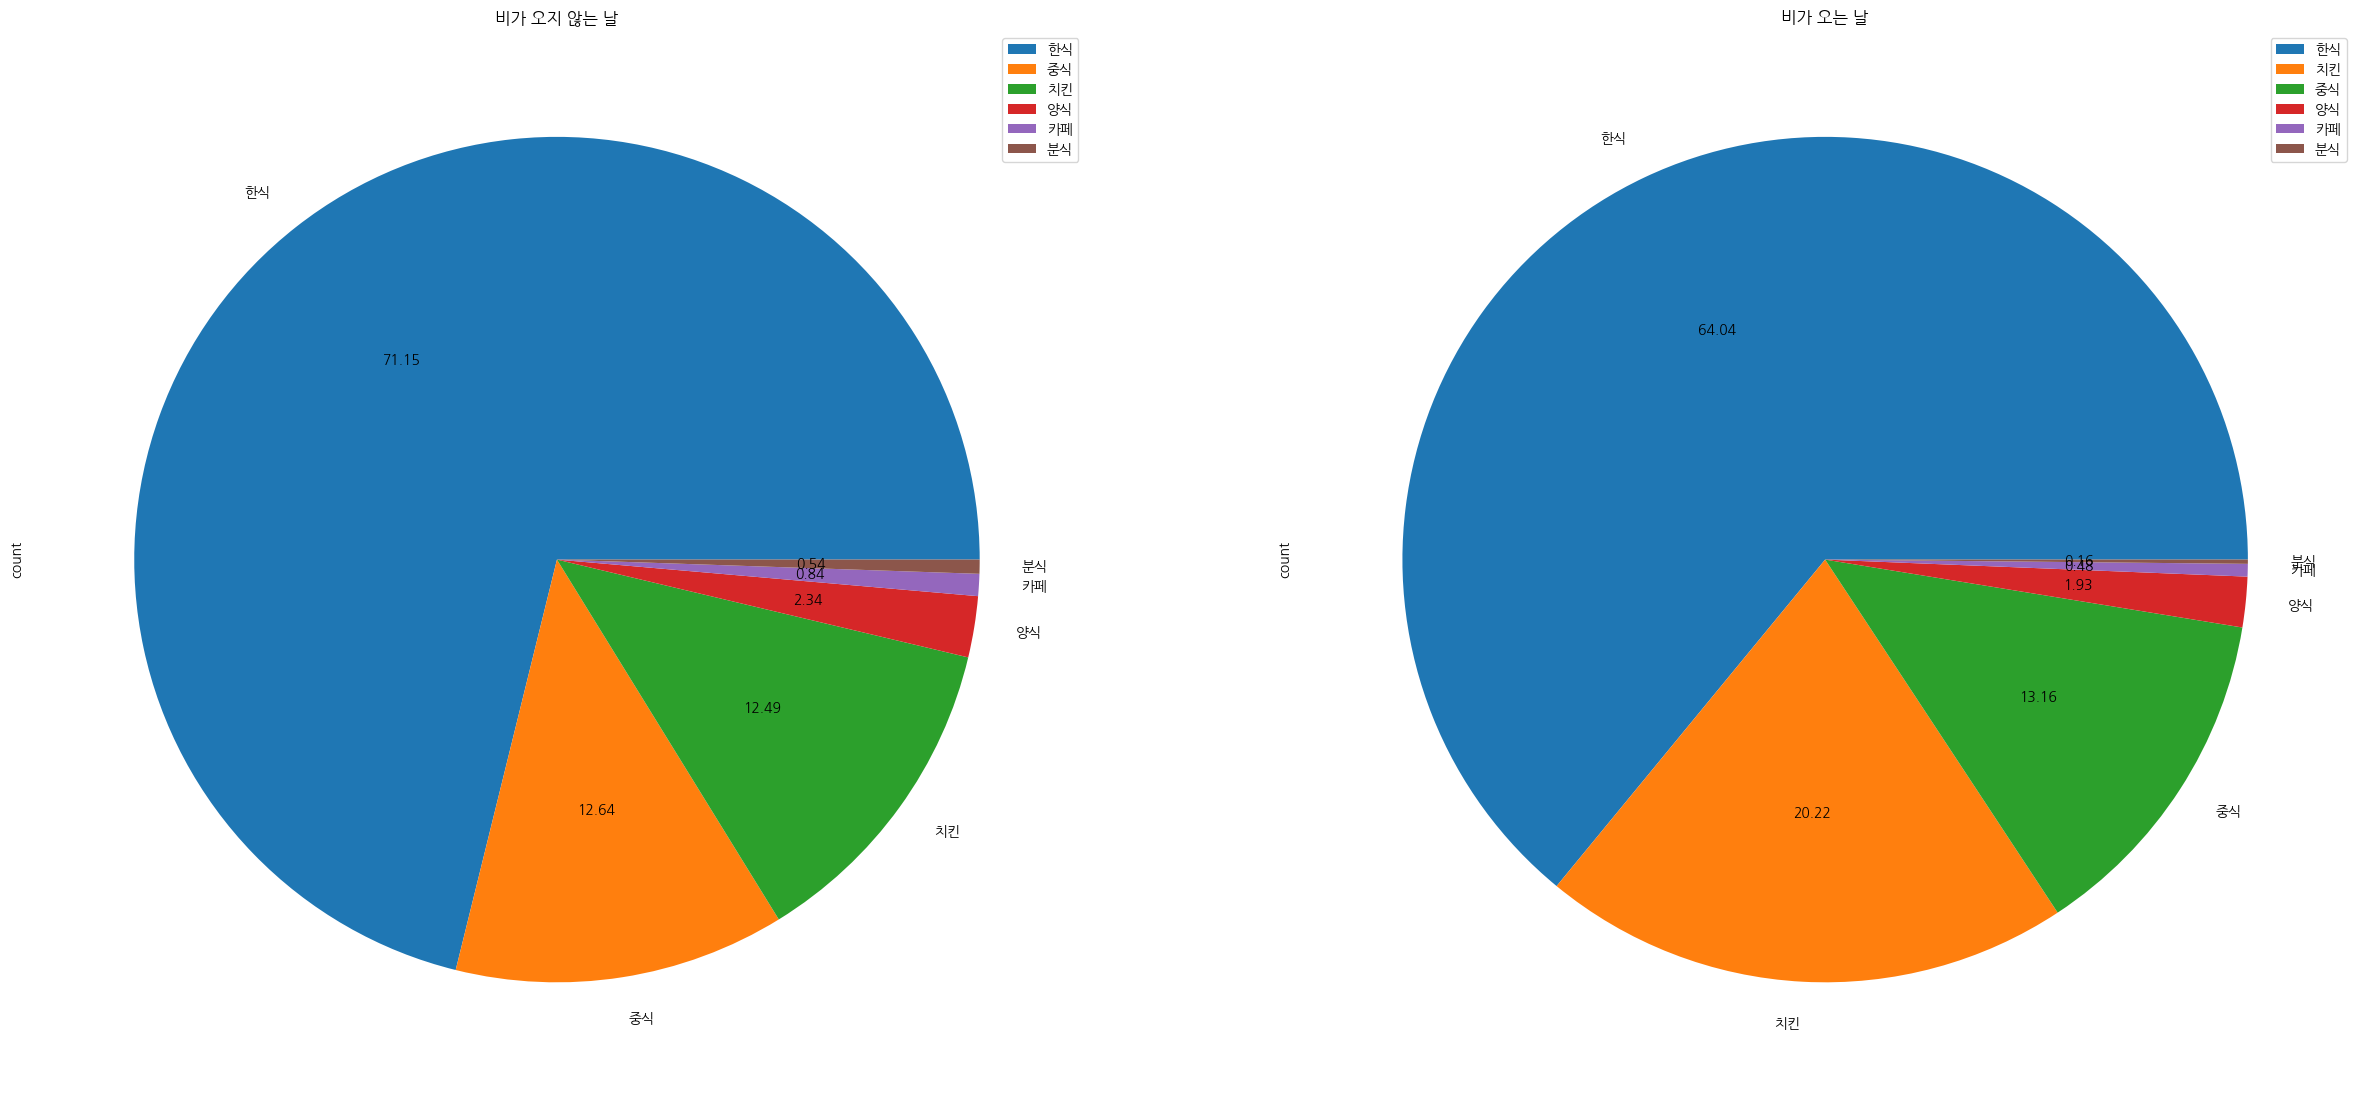

In [ ]:
figure, (ax1, ax2, ax3, ax4) = plt.subplots(ncols = 2, nrows = 2)
figure.set_size_inches(30, 15)
no_rain.plot.pie(y = "count", autopct= "%.2f", subplots = True, ax = ax1)
yes_rain.plot.pie(y = "count", autopct= "%.2f",subplots = True, ax = ax2)
ax3
ax4
ax1.set(title = "비가 오지 않는 날")
ax2.set(title = "비가 오는 날")


In [ ]:
temp_df = pd.read_csv("/content/drive/MyDrive/DATA/Tempdata_2008.csv", encoding = "cp949", parse_dates=["일시"])


temp_df.columns = ["지점번호", "지역", "일자", "평균기온", "최고기온", "최저기온", "최저기온시각", "일교차", "기타"]


temp_df = temp_df.drop(columns = [ "지점번호", "지역", "최고기온", "최저기온", "최저기온시각", "일교차", "기타"])

tot_df2 = pd.merge(call_df, temp_df, on = "일자")

,일자,중분류,평균기온
0,2020-08-23,중식,25.3
1,2020-08-30,양식,26.8
2,2020-08-25,치킨,29.9
3,2020-08-09,치킨,24.9
4,2020-08-09,중식,24.9
...,...,...,...
7716,2020-08-19,한식,27.1
7717,2020-08-21,한식,26.6
7718,2020-08-04,한식,27.0
7719,2020-08-15,치킨,26.1


In [ ]:

# 30도 이상일 때 배달량
hot_df = tot_df2[tot_df2["평균기온"] >= 30]
hot_df = pd.DataFrame(hot_df["중분류"].value_counts())

# 28도 이하일 때 배달량
cool_df = tot_df2[tot_df2["평균기온"] <= 28]
cool_df = pd.DataFrame(cool_df["중분류"].value_counts())



,count
중분류,
한식,150
치킨,39
중식,36
양식,26
카페,3


[Text(0.5, 1.0, '28도 이하인 날')]

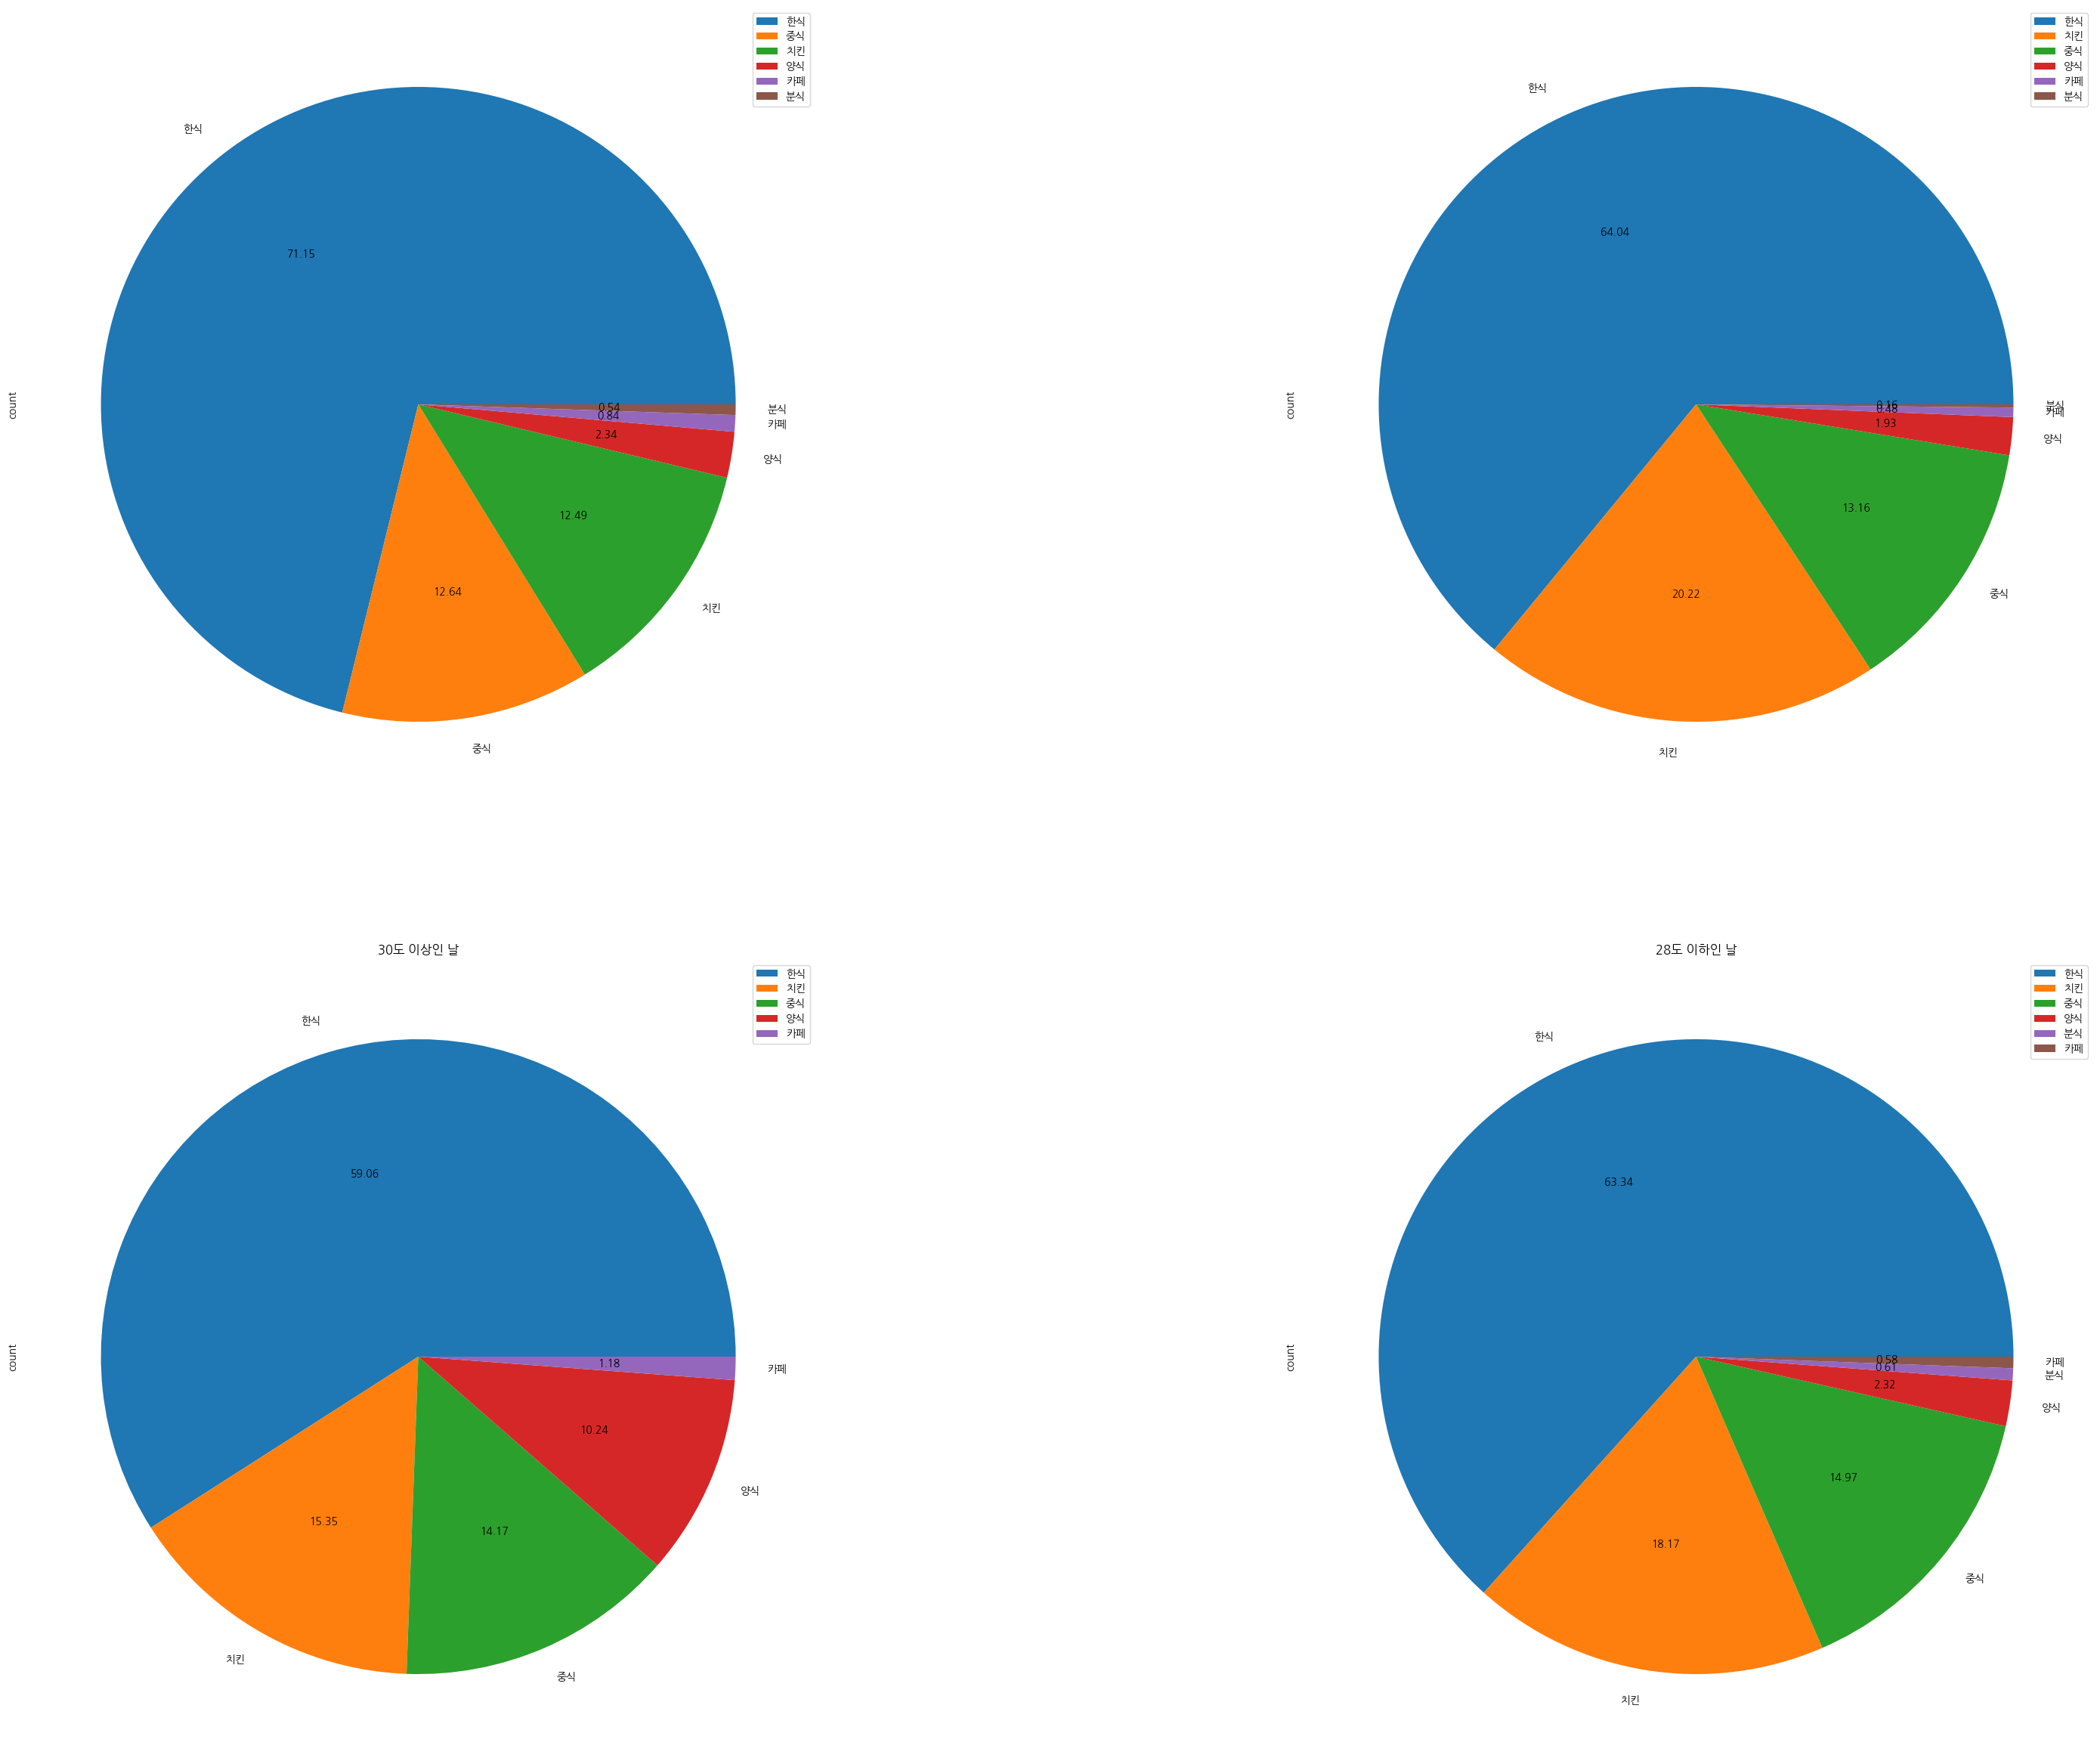

In [ ]:
figure, ((ax1,ax2),(ax3,ax4)) = plt.subplots(ncols = 2, nrows = 2)

# figure 객체의 사이즈를 가로 40, 세로 15로 설정하기
figure.set_size_inches(40,30)

# 원 그래프를 각 위치에 배치하기
no_rain.plot.pie(y = "count", autopct= "%.2f", subplots = True, ax = ax1)
yes_rain.plot.pie(y = "count", autopct= "%.2f",subplots = True, ax = ax2)
hot_df.plot.pie(y = "count",autopct= "%.2f", subplots = True, ax = ax3)
cool_df.plot.pie(y = "count",autopct= "%.2f", subplots = True, ax = ax4)

# 제목 설정하기
ax3.set(title = "30도 이상인 날")
ax4.set(title = "28도 이하인 날")